# Salience-map RPS baselines on DREGON-LM-V4 — final validation & visualisation

Evaluate the **`multif0_salience`** (LateDeep / Cuesta et al.) and **`basic_pitch`**
(Bittner et al. contour branch) salience-map RPS baselines on `DREGON-LM-V4/valid`,
and visualise — per sample — the input **spectrogram**, each model's **salience map**
(with GT + tracked-RPS overlaid), and the final **RPS trajectories vs ground truth**.

All plotting goes through the reusable `plots` machinery:
* the `"salience"` renderer (`plots.timeframe.renderers.render_salience` +
  `make_salience_series`) — added for this purpose,
* `plots.rps_prediction.salience_comparison.plot_salience_comparison` — the
  high-level per-sample figure used below; import it anywhere.

> Edit **`SAMPLE_IDS`** and **`CHANNEL`** in the visualisation section to explore
> other clips/channels.

## 1. Bootstrap (paths, imports)

In [1]:
import os, sys, json
from pathlib import Path

# This notebook may live in a git *worktree* whose src/ holds the new salience
# renderer, while the datasets/ + results/ live only in the main checkout
# (they are gitignored, so not copied into the worktree). Put this worktree's
# src first on the path, then chdir to whichever checkout actually has the data.
_here = Path.cwd().resolve()
_wt = next((p for p in [_here, *_here.parents] if (p / "src" / "utils" / "plots").exists()), _here)
sys.path.insert(0, str(_wt / "src"))

def _find_data_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "datasets").exists() and (p / "results").exists():
            return p
    parts = start.parts
    if ".claude" in parts:                       # strip .claude/worktrees/<name>
        main = Path(*parts[: parts.index(".claude")])
        if (main / "datasets").exists():
            return main
    return start

DATA_ROOT = _find_data_root(_wt)
os.chdir(DATA_ROOT)
print("worktree src :", _wt / "src")
print("data root    :", DATA_ROOT)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

worktree src : /home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/.claude/worktrees/typst-reports-slides-2/src
data root    : /home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression


## 2. Configuration — checkpoints & dataset

The `multif0_salience` checkpoint was trained with `--hcqt_fmin 32.7` (C1 → 3 harmonics, 360-bin grid); `basic_pitch` uses its native 264-bin contour grid. Both run at native 16 kHz. Other `multif0_salience` speed variants exist under `results/rps_baselines_v4/` (`_faster` = fused branches, `_fastest` = stacked HCQT) — swap the path below to evaluate them.

In [2]:
from models.salience_rps import LateDeepSalience, BasicPitchSalience

DATASET = "datasets/DREGON-LM-V4/valid"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# name -> (constructor, checkpoint path)
CHECKPOINTS = {
    "multif0_salience": (
        lambda: LateDeepSalience(n_fft=2048, hop_length=512, num_rotors=4, fmin=32.7),
        "results/rps_baselines_v4/multif0_salience/best_multif0_salience.pt",
    ),
    "multif0_salience_fastest": (  # stacked HCQT + fused branches (fmin=27.5, 4 harmonics)
        lambda: LateDeepSalience(n_fft=2048, hop_length=512, num_rotors=4,
                                 fmin=27.5, stacked=True, fused_branches=True),
        "results/rps_baselines_v4/multif0_salience_fastest/best_multif0_salience.pt",
    ),
    "basic_pitch": (
        lambda: BasicPitchSalience(n_fft=2048, hop_length=512, num_rotors=4),
        "results/rps_baselines_v4/basic_pitch/best_basic_pitch_salience.pt",
    ),
}

def load_models(device=DEVICE):
    models = {}
    for name, (ctor, ckpt) in CHECKPOINTS.items():
        m = ctor().to(device)
        m.load_state_dict(torch.load(ckpt, map_location=device), strict=True)
        m.eval()
        models[name] = m
    return models

models = load_models()
{k: f"{sum(p.numel() for p in v.parameters()):,} params" for k, v in models.items()}

{'multif0_salience': '1,249,492 params',
 'multif0_salience_fastest': '1,250,296 params',
 'basic_pitch': '16,782 params'}

## 3. Final validation metrics on `DREGON-LM-V4/valid`

Reuses the project's `evaluate()` (PIT-aware MSE/RMSE/MAE/R², comparable across all RPS model families). DREGON-LM-V4 is 8-channel; channels are flattened into the batch, so metrics average over all clip×channel items. Results are cached to `results/dregon_v4_eval/salience_baselines_final_valid.json` — set `RECOMPUTE=True` to re-run (slow: Hungarian tracking on CPU).

In [3]:
from torch.utils.data import DataLoader
from train_rps_predictor import DREGONRPSDataset, evaluate

EVAL_JSON = "results/dregon_v4_eval/salience_baselines_final_valid.json"
RECOMPUTE = False
TRACK_THRESHOLD = 0.3

if not RECOMPUTE and os.path.exists(EVAL_JSON):
    eval_data = json.load(open(EVAL_JSON))
    results = eval_data["results"]
    print(f"loaded cached eval ({eval_data['n_samples']} samples, device={eval_data.get('device')})")
else:
    ds = DREGONRPSDataset(DATASET, n_fft=2048, hop_length=512)
    loader = DataLoader(ds, batch_size=2, shuffle=False, num_workers=2)
    results = {}
    for name, model in models.items():
        m = evaluate(model, loader, DEVICE, len(ds), pit_eval=True,
                     track_threshold=TRACK_THRESHOLD, progress=True)
        m["rmse"] = m["mse"] ** 0.5
        results[name] = m
    os.makedirs("results/dregon_v4_eval", exist_ok=True)
    json.dump({"dataset": DATASET, "n_samples": len(ds), "track_threshold": TRACK_THRESHOLD,
               "pit_eval": True, "device": DEVICE,
               "checkpoints": {k: v[1] for k, v in CHECKPOINTS.items()},
               "results": results}, open(EVAL_JSON, "w"), indent=2)

cols = ["mse", "rmse", "mae_frame", "mae_clip", "r2", "r2_median"]
df = pd.DataFrame(results).T[cols]
df.columns = ["PIT-MSE", "RMSE (Hz)", "MAE frame (Hz)", "MAE clip (Hz)", "R²", "R² median"]
df.round(3)

loaded cached eval (30 samples, device=cpu)


,PIT-MSE,RMSE (Hz),MAE frame (Hz),MAE clip (Hz),R²,R² median
multif0_salience,39.679549,6.299171,3.401189,2.985561,0.187752,0.330461
basic_pitch,540.135356,23.240812,16.187813,15.901481,-16.213301,-10.284994
multif0_salience_fastest,41.26839,6.424048,3.583653,3.278852,0.105816,0.357713


## 4. Pick interesting samples

Rank clips by per-model tracking error (channel 0) to surface the *interesting* ones — e.g. where the two models disagree most, or where tracking is best/worst. `SAMPLE_IDS` defaults to three picked this way; override it freely.

In [4]:
import glob
from plots.rps_prediction.sample_comparison import _load_sample
from plots.rps_prediction.salience_comparison import model_rps_prediction, select_channel

SAMPLE_PATHS = sorted(glob.glob(os.path.join(DATASET, "sample_*")))

def per_sample_mae(channel=0):
    """Per-sample clip-MAE (Hz) for each model on one channel + their disagreement."""
    rows = []
    for sp in SAMPLE_PATHS:
        s = _load_sample(sp)
        mono = select_channel(s["audio"], channel)
        dur = mono.duration
        row = {"sample": Path(sp).name}
        preds = {}
        for name, model in models.items():
            pred = model_rps_prediction(model, mono, device=DEVICE)
            t = np.linspace(mono.t_start, mono.t_start + dur, pred.shape[-1])
            gt = np.asarray(s["rps"].interpolate(t))
            row[f"mae_{name}"] = float(np.abs(pred.mean(0).mean() - gt.mean(0).mean()))  # clip-level
            row[f"maeframe_{name}"] = float(np.abs(pred - gt).mean())
            preds[name] = pred.mean(0)
        # Mean pairwise disagreement across all models (works for 2+ models).
        names = list(preds)
        pairs = [(a, b) for i, a in enumerate(names) for b in names[i + 1:]]
        row["disagree"] = float(np.mean([np.abs(preds[a] - preds[b]).mean() for a, b in pairs])) if pairs else 0.0
        rows.append(row)
    return pd.DataFrame(rows).set_index("sample")

rank = per_sample_mae(channel=0)
rank.round(2).sort_values("disagree", ascending=False).head(10)

,mae_multif0_salience,maeframe_multif0_salience,mae_multif0_salience_fastest,maeframe_multif0_salience_fastest,mae_basic_pitch,maeframe_basic_pitch,disagree
sample,,,,,,,
sample_00020,17.77,23.67,19.57,26.23,31.29,38.76,33.91
sample_00000,1.58,7.84,1.10,5.84,22.30,22.30,15.61
sample_00025,1.91,8.21,0.96,7.14,18.68,22.32,13.73
sample_00024,1.65,9.38,1.49,8.03,18.29,22.01,13.41
sample_00015,2.38,7.13,1.49,6.74,16.99,20.10,12.91
sample_00026,1.51,6.90,0.97,6.88,17.14,20.73,12.44
sample_00019,2.04,8.15,1.06,7.23,16.50,20.17,12.37
sample_00012,2.33,8.83,2.39,6.16,14.98,18.96,11.88
sample_00006,1.86,10.31,4.86,8.13,15.35,20.14,11.48


In [5]:
# Three distinct, interesting picks: cleanest multif0 track, hardest multif0
# track, and the clip where the two models disagree most. Pad from the
# disagreement ranking if any coincide, so we always get N_PICK samples.
N_PICK = 3
_seed = [
    rank["maeframe_multif0_salience"].idxmin(),   # multif0 at its best
    rank["maeframe_multif0_salience"].idxmax(),   # multif0's hardest clip
    rank["disagree"].idxmax(),                     # models diverge most
]
_by_disagree = list(rank["disagree"].sort_values(ascending=False).index)
SAMPLE_IDS = list(dict.fromkeys(_seed + _by_disagree))[:N_PICK]
print("auto-picked SAMPLE_IDS =", SAMPLE_IDS)
# SAMPLE_IDS = ["sample_00002", "sample_00010", "sample_00021"]  # <- override manually

auto-picked SAMPLE_IDS = ['sample_00026', 'sample_00020', 'sample_00000']


## 5. Visualise the selected samples

For each sample: **spectrogram** → per-model **salience map** (GT dotted, tracked RPS solid, overlaid on the heatmap) → **RPS vs GT** trajectories. Change `CHANNEL` to inspect a different microphone.

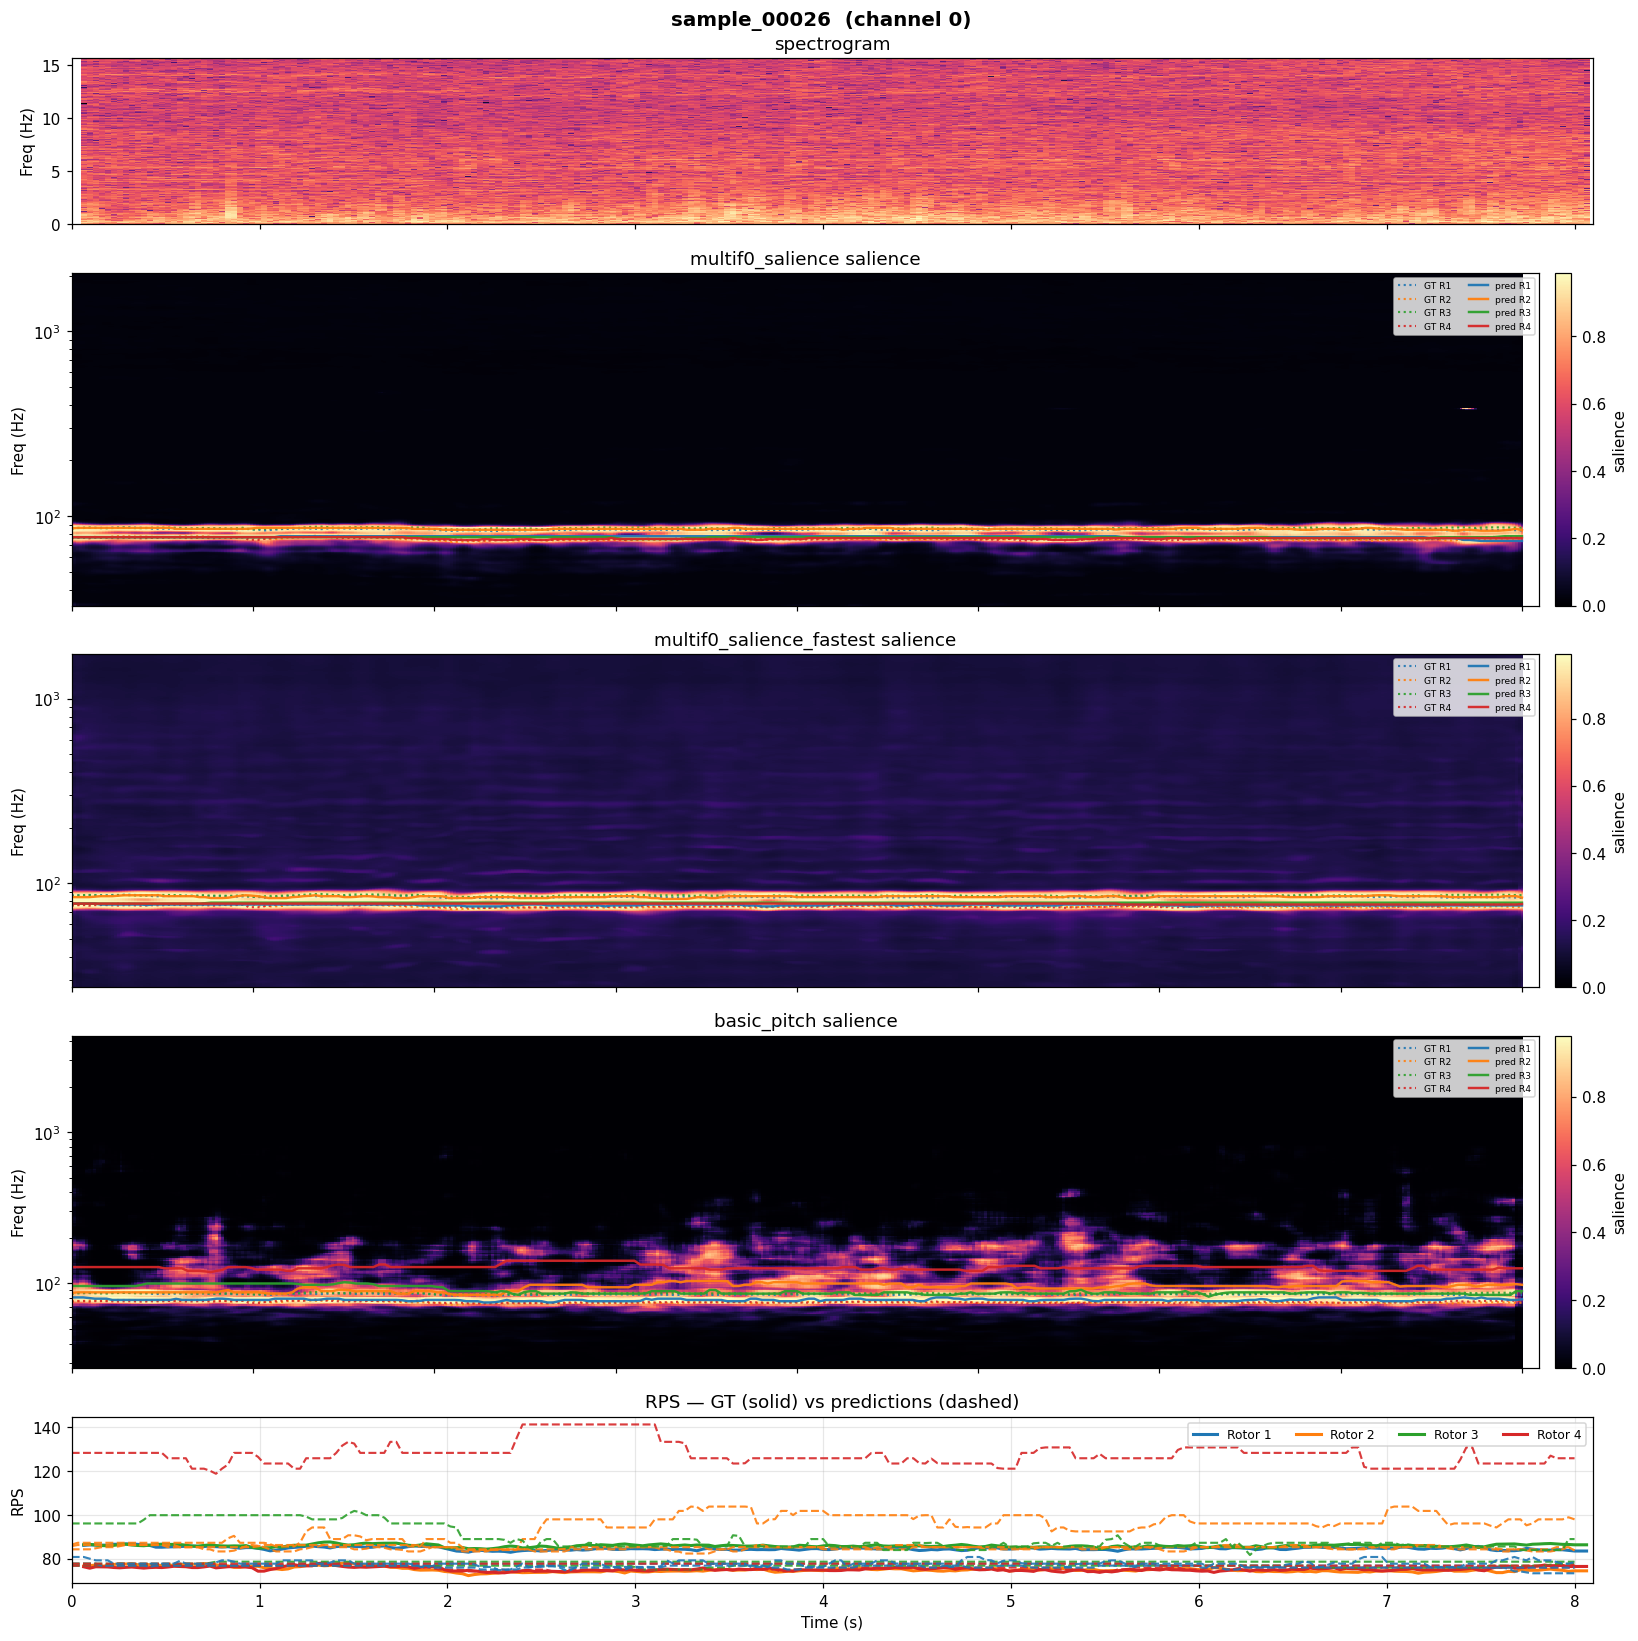

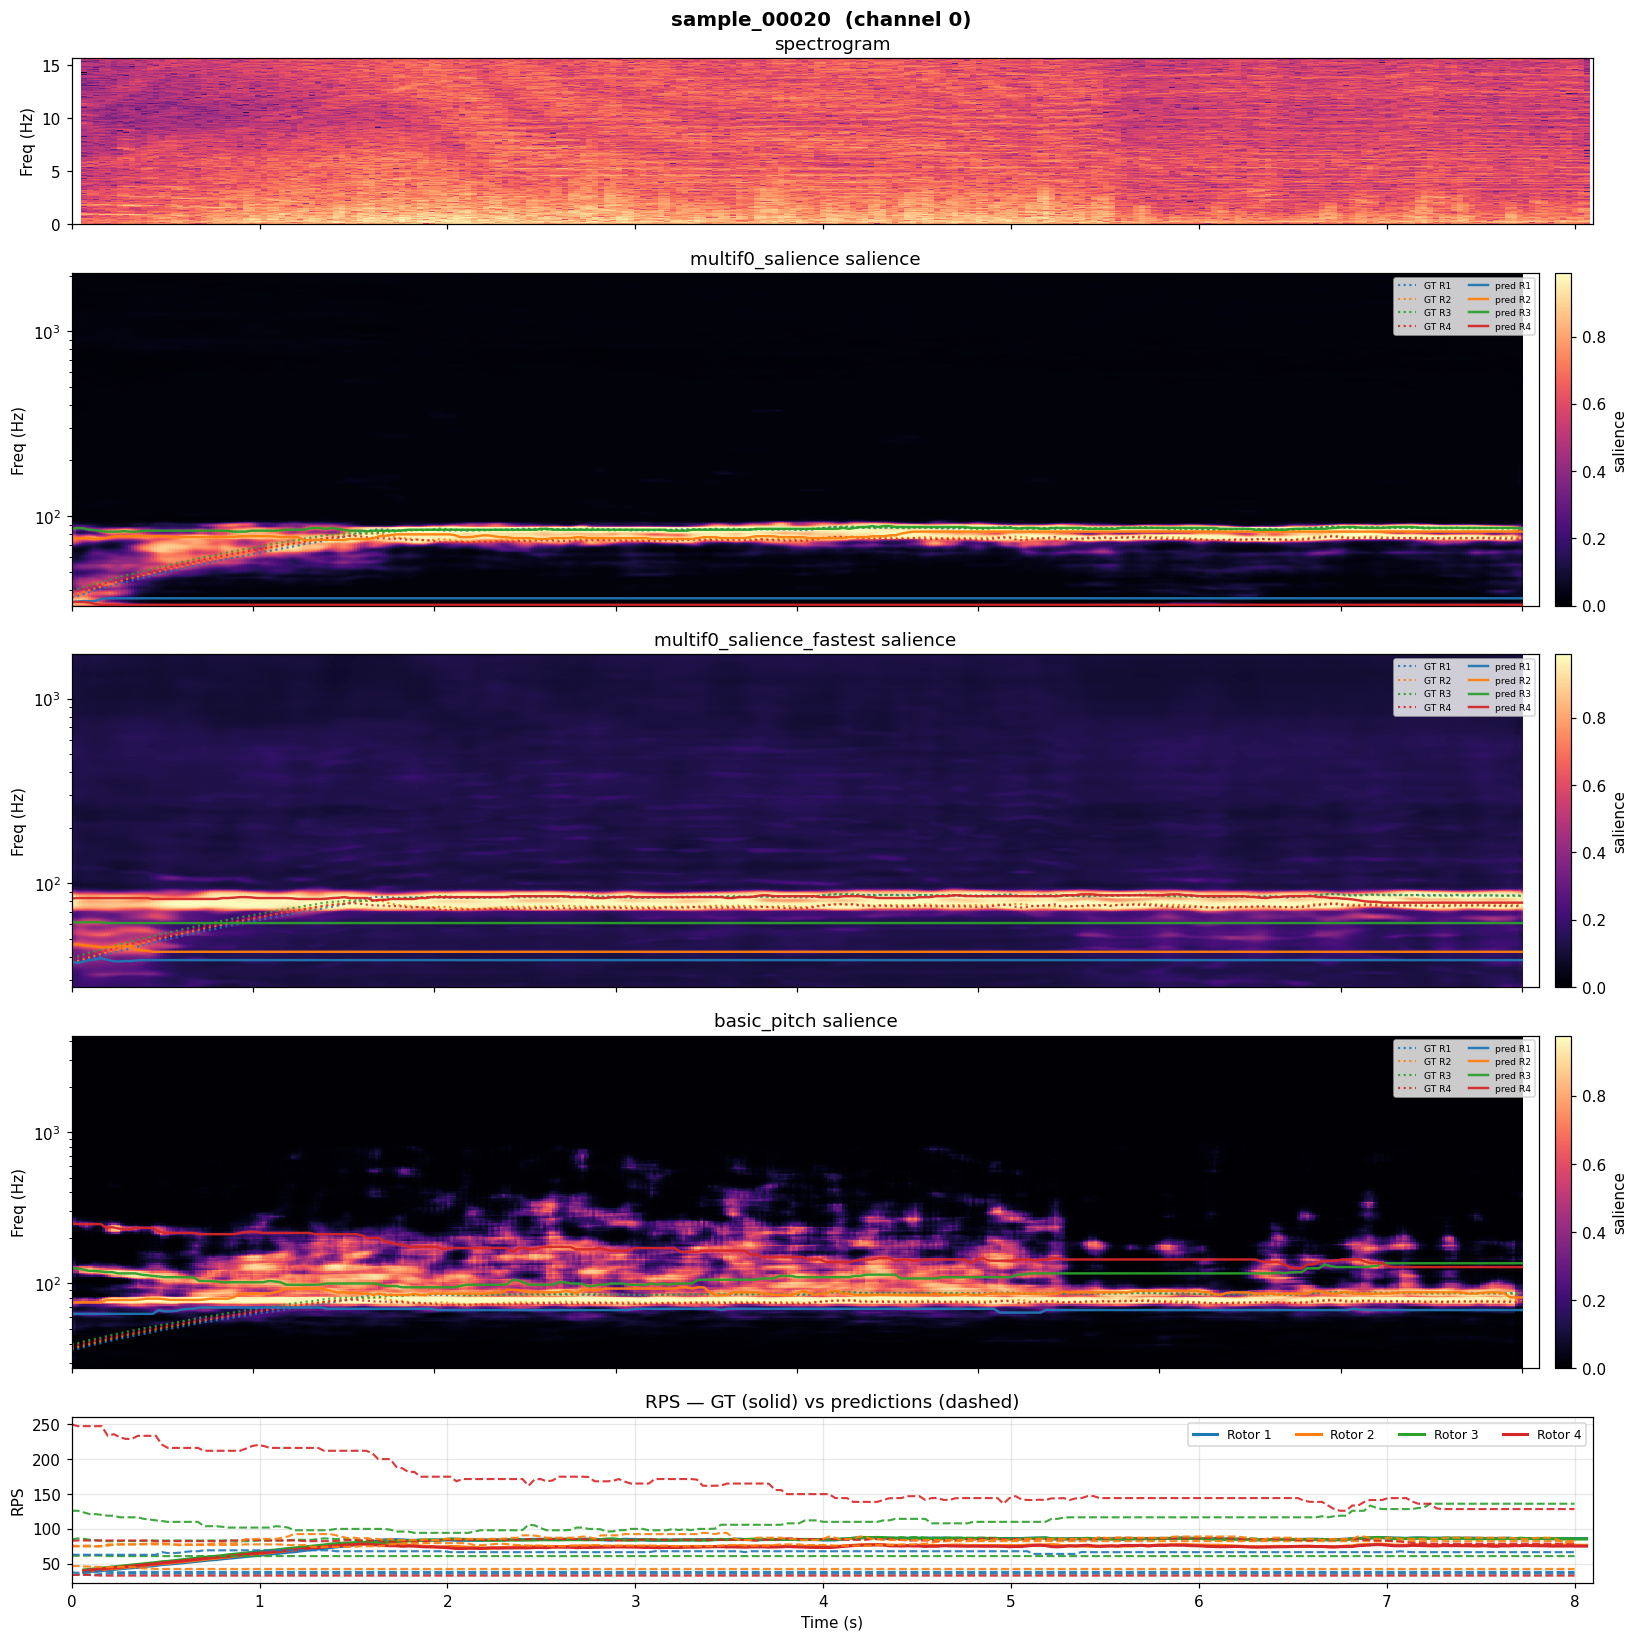

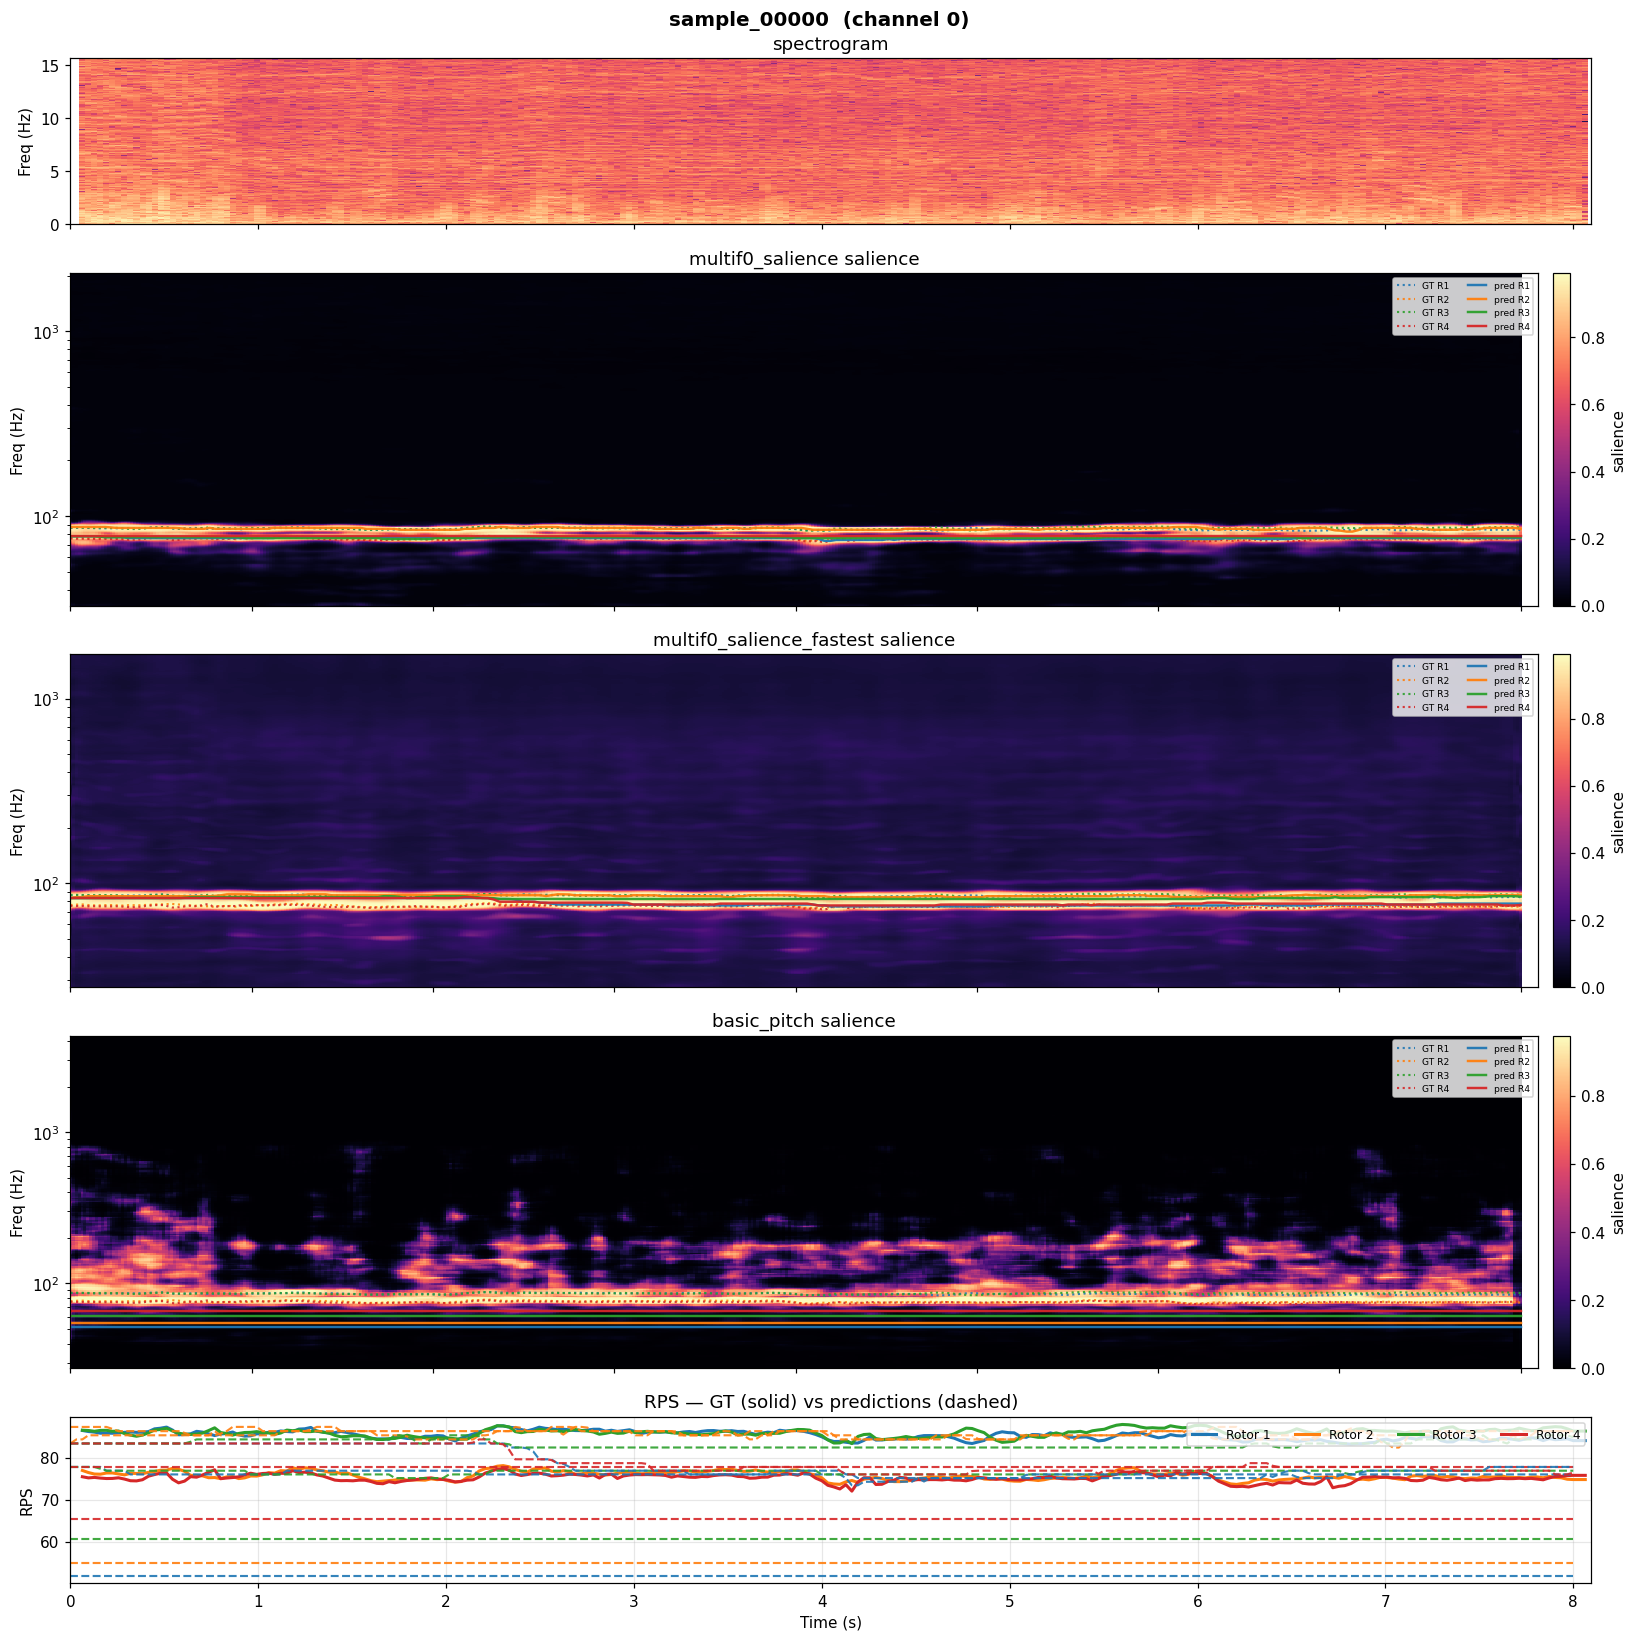

In [6]:
from plots.rps_prediction.salience_comparison import plot_salience_comparison

CHANNEL = 0
SALIENCE_VMAX = "auto"   # or a float in (0, 1] for a fixed colour scale

for sid in SAMPLE_IDS:
    sample = _load_sample(os.path.join(DATASET, sid))
    fig = plot_salience_comparison(sample, models, channel=CHANNEL,
                                   device=DEVICE, salience_vmax=SALIENCE_VMAX)
    fig.suptitle(f"{sid}  (channel {CHANNEL})", y=1.005, fontsize=13, fontweight="bold")
    plt.show()

## 6. Play around — single sample / channel

Tweak `SAMPLE_ID` and `CHANNEL` and re-run. Helpers (`model_salience_series`, `model_rps_prediction`, `build_salience_frame`, `plot_salience_comparison`) live in `plots.rps_prediction.salience_comparison` and are reusable elsewhere.

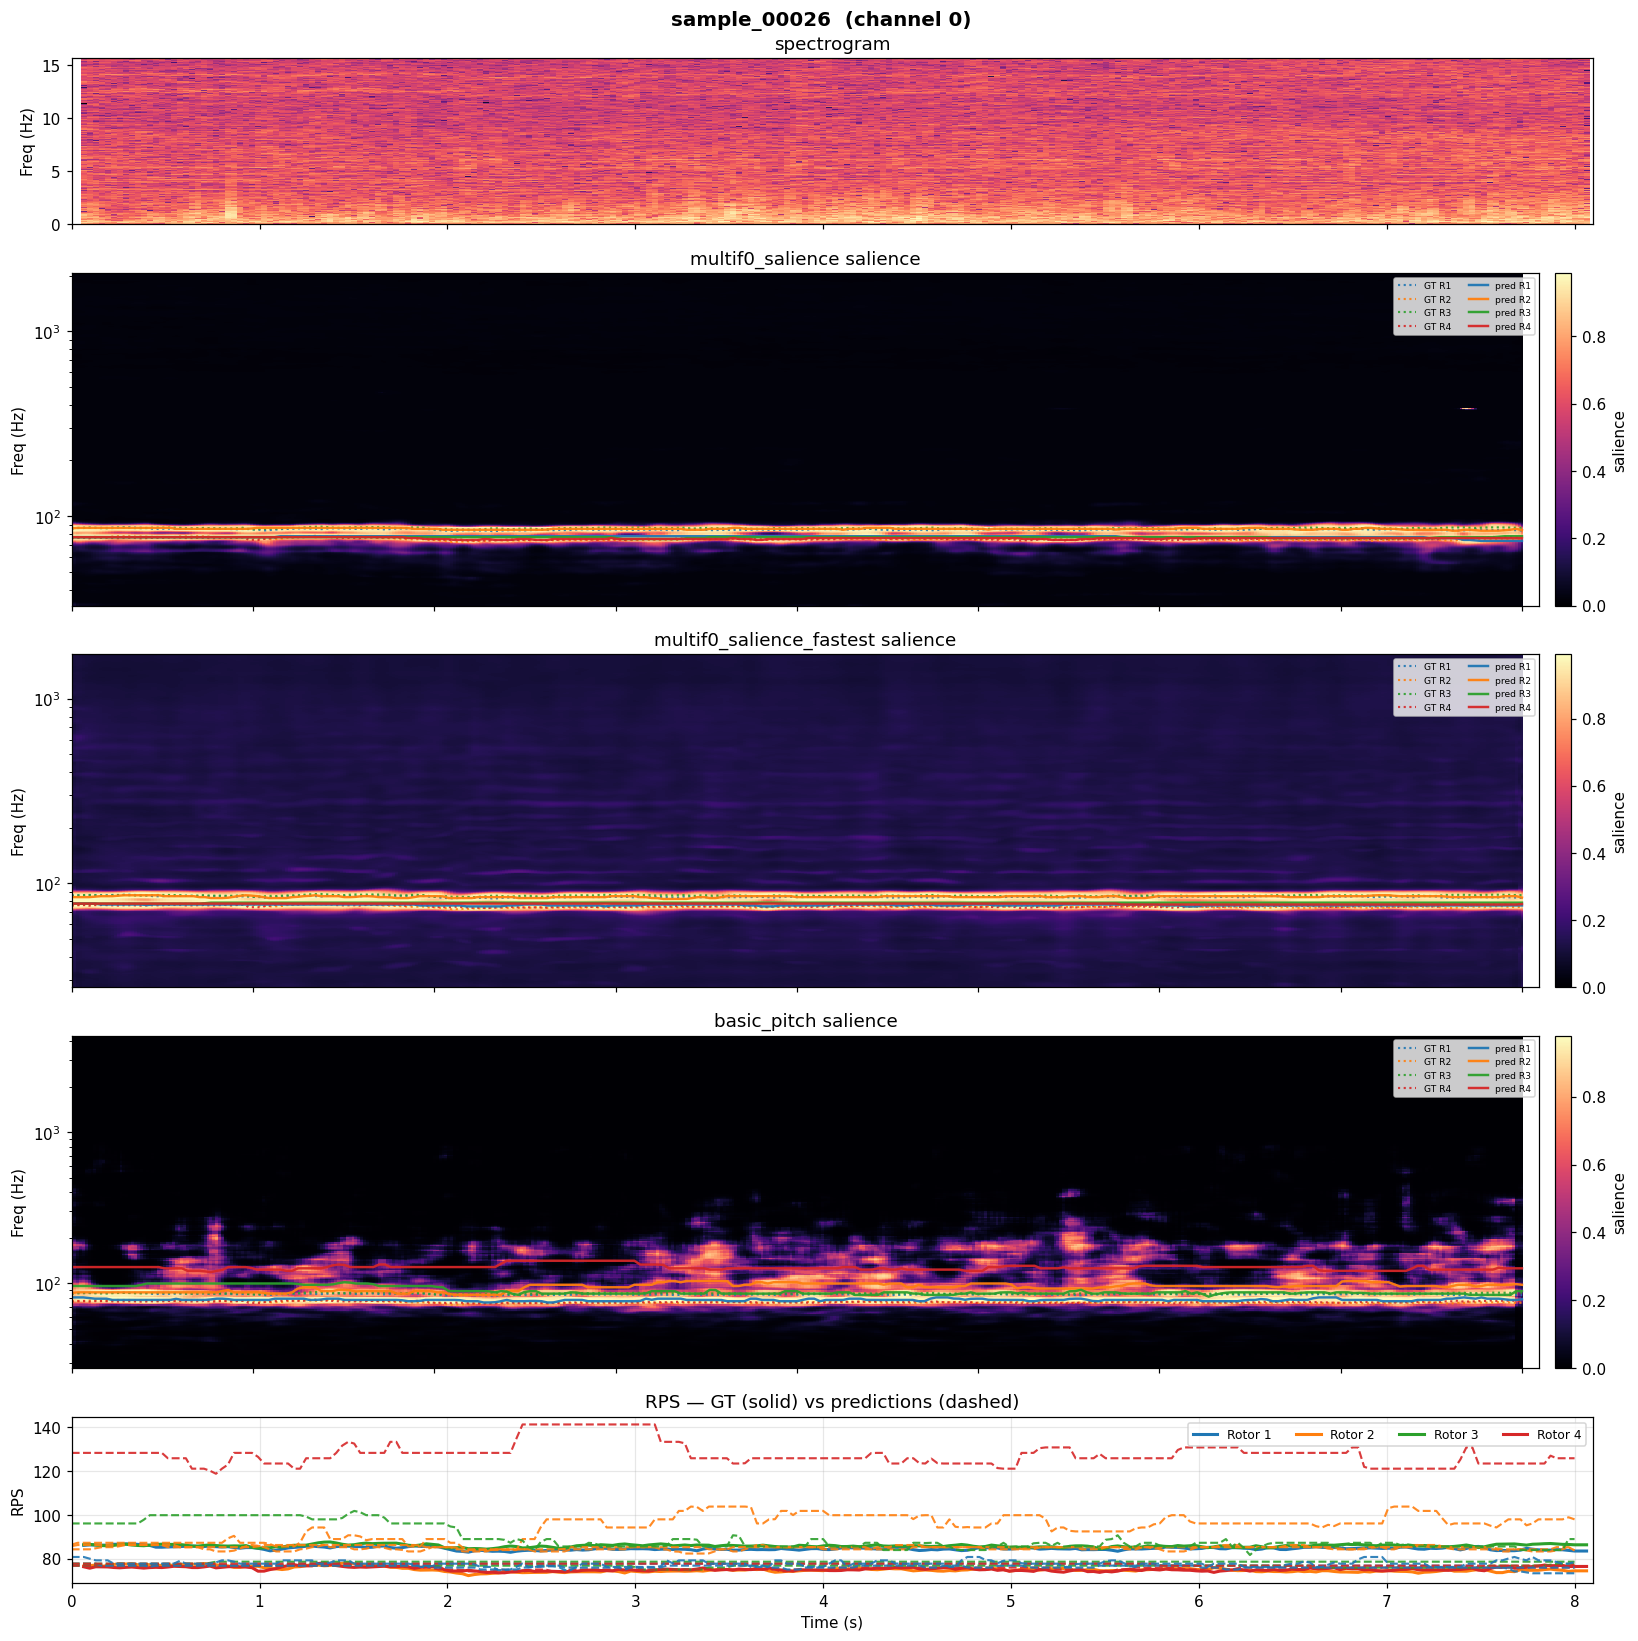

In [7]:
SAMPLE_ID = SAMPLE_IDS[0]
CHANNEL = 0

sample = _load_sample(os.path.join(DATASET, SAMPLE_ID))
fig = plot_salience_comparison(sample, models, channel=CHANNEL, device=DEVICE,
                               salience_vmax="auto")
fig.suptitle(f"{SAMPLE_ID}  (channel {CHANNEL})", y=1.005, fontsize=13, fontweight="bold")
plt.show()